# Tune LightGBM (28-Day) with Optuna
This notebook tunes LightGBM on the `lgbm_28` dataset using Optuna, then compares tuned vs untuned performance and visual diagnostics.

## 1) Imports and Paths
This cell imports all dependencies and defines data/report paths.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor

try:
    import optuna
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna'])
    import optuna

RANDOM_SEED = 42
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed' / 'lgbm_28'
REPORTS_DIR = ROOT / 'artifacts' / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_DIR:', DATA_DIR)
print('REPORTS_DIR:', REPORTS_DIR)

DATA_DIR: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\data\processed\lgbm_28
REPORTS_DIR: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Load Train/Val/Test + Validate Required Schema
This cell loads the 28-day splits, enforces the exact required columns, and confirms row/column/null counts.

In [2]:
required_cols = [
    'item_id', 'date', 'aggregated_sales_28', 'is_month_end',
    'sales_lag_28', 'sales_lag_14', 'sales_lag_7', 'sales_lag_1', 'sales_lag_2', 'sales_lag_4',
    'sales_roll_mean_28', 'sales_roll_mean_14', 'sales_roll_mean_7', 'sales_roll_mean_2', 'sales_roll_mean_4',
    'sales_roll_std_28', 'sales_roll_std_14', 'sales_roll_std_4',
    'aggregated_sell_price', 'discount_depth', 'price_lag_1', 'price_change_bucket',
    'event_christmas_28', 'event_easter_28', 'event_eid_al_fitr_28', 'event_eid_al_adha_28',
    'event_fathers_day_28', 'event_halloween_28', 'event_mothers_day_28', 'event_newyear_28',
    'event_orthodox_christmas_28', 'event_orthodox_easter_28', 'event_ramadan_starts_28',
    'event_thanksgiving_28', 'event_valentines_day_28',
    'item_mean_train', 'item_std_train', 'item_cv_train', 'weeks_since_first_seen', 'snap_relevant'
]

train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df = pd.read_csv(DATA_DIR / 'val.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    missing = [c for c in required_cols if c not in d.columns]
    extra = [c for c in d.columns if c not in required_cols]
    if missing:
        raise ValueError(f'{name} split missing required columns: {missing}')
    if extra:
        raise ValueError(f'{name} split has unexpected extra columns: {extra}')

    d['date'] = pd.to_datetime(d['date'], errors='coerce')
    if d['date'].isna().any():
        raise ValueError(f'{name} split has invalid date values.')

    d = d[required_cols].copy()
    if name == 'train':
        train_df = d
    elif name == 'val':
        val_df = d
    else:
        test_df = d

summary = pd.DataFrame([
    {'split': 'train', 'rows': len(train_df), 'cols': train_df.shape[1], 'null_cells': int(train_df.isna().sum().sum())},
    {'split': 'val', 'rows': len(val_df), 'cols': val_df.shape[1], 'null_cells': int(val_df.isna().sum().sum())},
    {'split': 'test', 'rows': len(test_df), 'cols': test_df.shape[1], 'null_cells': int(test_df.isna().sum().sum())},
])
summary

,split,rows,cols,null_cells
0,train,64665,40,0
1,val,14370,40,0
2,test,15807,40,0


## 3) Define Target and Features
This cell sets the target and prepares feature matrices with robust numeric/categorical detection.

In [3]:
target_col = 'aggregated_sales_28'
feature_cols = [c for c in train_df.columns if c != target_col]

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()
X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

categorical_features = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(X_train[c])]
numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X_train[c])]

print('Target:', target_col)
print('Feature count:', len(feature_cols))
print('Numeric:', len(numeric_features), 'Categorical:', len(categorical_features))
print('Categorical features:', categorical_features)

Target: aggregated_sales_28
Feature count: 39
Numeric: 37 Categorical: 2
Categorical features: ['item_id', 'date']


## 4) Helpers and Baseline Model
This cell defines metrics, a pipeline builder, then trains an untuned LightGBM baseline.

In [4]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom))

def compute_metrics(y_true, y_pred):
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'SMAPE': float(smape(y_true, y_pred)),
        'BIAS': float(np.mean(np.asarray(y_pred) - np.asarray(y_true))),
    }

def make_lgbm_pipeline(model_kwargs):
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features),
        ]
    )

    model = LGBMRegressor(random_state=RANDOM_SEED, **model_kwargs)
    return Pipeline(steps=[('prep', preprocessor), ('model', model)])

untuned_params = dict(
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=64,
    min_child_samples=20,
    feature_fraction=1.0,
    bagging_fraction=1.0,
)

untuned_lgbm = make_lgbm_pipeline(untuned_params)
untuned_lgbm.fit(X_train, y_train)

pred_untuned_val = untuned_lgbm.predict(X_val)
pred_untuned_test = untuned_lgbm.predict(X_test)

baseline_val = compute_metrics(y_val, pred_untuned_val)
baseline_test = compute_metrics(y_test, pred_untuned_test)

pd.DataFrame([
    {'split': 'val', 'model': 'UntunedLGBM_28d', **baseline_val},
    {'split': 'test', 'model': 'UntunedLGBM_28d', **baseline_test},
])

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", l

[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007540 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7742
[LightGBM] [Info] Number of data points in the train set: 64665, number of used features: 1517
[LightGBM] [Info] Start training from score 57.248326
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=1.0,

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,split,model,MAE,RMSE,SMAPE,BIAS
0,val,UntunedLGBM_28d,8.795958,21.905980,45.783333,2.674509
1,test,UntunedLGBM_28d,6.315032,13.904094,32.625599,-0.788037


## 5) Optuna Objective (with Stability Penalty)
This cell defines the Optuna objective using the same parameter ranges from notebook 7 and adds a penalty to reduce overfitting/instability.

In [5]:
def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
    }

    model = make_lgbm_pipeline(params)
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)

    smape_train = smape(y_train, pred_train)
    smape_val = smape(y_val, pred_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
    bias_val = np.mean(pred_val - y_val)

    overfit_gap = abs(smape_val - smape_train)
    objective_value = smape_val + 0.40 * overfit_gap + 0.15 * abs(bias_val) + 0.05 * rmse_val
    return float(objective_value)

## 6) Run Optuna Search
This cell runs Bayesian optimization and shows the best objective value and best parameters.

In [6]:
N_TRIALS = 60
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

print('Best objective:', study.best_value)
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

[I 2026-04-13 22:06:13,758] A new study created in memory with name: no-name-b4669bdd-e71b-4890-b6ff-f98a1e4e4b9c


[LightGBM] [Warning] feature_fraction is set=0.5780093202212182, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5780093202212182
[LightGBM] [Warning] bagging_fraction is set=0.5779972601681014, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5779972601681014
[LightGBM] [Warning] feature_fraction is set=0.5780093202212182, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5780093202212182
[LightGBM] [Warning] bagging_fraction is set=0.5779972601681014, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5779972601681014
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006813 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4864
[LightGBM] [Info] Number of data points in the train set: 64665, number of used features: 79
[LightGBM] [Info] Start training from score 57.248326


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.5780093202212182, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5780093202212182
[LightGBM] [Warning] bagging_fraction is set=0.5779972601681014, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5779972601681014


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2026-04-13 22:06:17,343] Trial 0 finished with value: 55.315422968525745 and parameters: {'num_leaves': 69, 'learning_rate': 0.09556428757689246, 'n_estimators': 759, 'min_child_samples': 64, 'feature_fraction': 0.5780093202212182, 'bagging_fraction': 0.5779972601681014}. Best is trial 0 with value: 55.315422968525745.


...

[LightGBM] [Warning] feature_fraction is set=0.8489259543214814, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8489259543214814
[LightGBM] [Warning] bagging_fraction is set=0.7995040512897865, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7995040512897865
[LightGBM] [Warning] feature_fraction is set=0.8489259543214814, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8489259543214814
[LightGBM] [Warning] bagging_fraction is set=0.7995040512897865, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7995040512897865
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008920 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7738
[LightGBM] [Info] Number of data points in the train set: 64665, number of used features: 1516
[LightGBM] [Info] Start training from score 57.248326


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.8489259543214814, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8489259543214814
[LightGBM] [Warning] bagging_fraction is set=0.7995040512897865, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7995040512897865


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2026-04-13 22:12:11,009] Trial 59 finished with value: 49.88156423270173 and parameters: {'num_leaves': 128, 'learning_rate': 0.034295860824352556, 'n_estimators': 151, 'min_child_samples': 37, 'feature_fraction': 0.8489259543214814, 'bagging_fraction': 0.7995040512897865}. Best is trial 5 with value: 49.09016345462494.


[LightGBM] [Warning] feature_fraction is set=0.8489259543214814, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8489259543214814
[LightGBM] [Warning] bagging_fraction is set=0.7995040512897865, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7995040512897865
Best objective: 49.09016345462494
Best params:
  num_leaves: 99
  learning_rate: 0.02534717113185624
  n_estimators: 158
  min_child_samples: 96
  feature_fraction: 0.9828160165372797
  bagging_fraction: 0.9041986740582306


## 7) Train Tuned Model and Compare vs Untuned
This cell trains the tuned model and compares tuned vs untuned metrics on validation and test, including val-test gaps.

In [7]:
best_params = study.best_params.copy()
tuned_lgbm = make_lgbm_pipeline(best_params)
tuned_lgbm.fit(X_train, y_train)

pred_tuned_val = tuned_lgbm.predict(X_val)
pred_tuned_test = tuned_lgbm.predict(X_test)

tuned_val = compute_metrics(y_val, pred_tuned_val)
tuned_test = compute_metrics(y_test, pred_tuned_test)

metrics_rows = [
    {'split': 'val', 'model': 'UntunedLGBM_28d', **baseline_val},
    {'split': 'test', 'model': 'UntunedLGBM_28d', **baseline_test},
    {'split': 'val', 'model': 'TunedLGBM_28d', **tuned_val},
    {'split': 'test', 'model': 'TunedLGBM_28d', **tuned_test},
]
metrics_df = pd.DataFrame(metrics_rows)
metrics_df['BIAS_abs'] = metrics_df['BIAS'].abs()
metrics_df = metrics_df[['split', 'model', 'MAE', 'RMSE', 'SMAPE', 'BIAS', 'BIAS_abs']]

gap_rows = []
for model_name in metrics_df['model'].unique():
    tmp = metrics_df[metrics_df['model'] == model_name].set_index('split')
    gap_rows.append({
        'model': model_name,
        'MAE_gap_abs': abs(tmp.loc['test', 'MAE'] - tmp.loc['val', 'MAE']),
        'RMSE_gap_abs': abs(tmp.loc['test', 'RMSE'] - tmp.loc['val', 'RMSE']),
        'SMAPE_gap_abs': abs(tmp.loc['test', 'SMAPE'] - tmp.loc['val', 'SMAPE']),
        'BIAS_gap_abs': abs(tmp.loc['test', 'BIAS'] - tmp.loc['val', 'BIAS']),
    })
gap_df = pd.DataFrame(gap_rows)

display(metrics_df.sort_values(['split', 'SMAPE']))
display(gap_df.sort_values('SMAPE_gap_abs'))

[LightGBM] [Warning] feature_fraction is set=0.9828160165372797, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9828160165372797
[LightGBM] [Warning] bagging_fraction is set=0.9041986740582306, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9041986740582306
[LightGBM] [Warning] feature_fraction is set=0.9828160165372797, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9828160165372797
[LightGBM] [Warning] bagging_fraction is set=0.9041986740582306, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9041986740582306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009280 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4864
[LightGBM] [Info] Number of data points in the train set: 64665, number of used features: 79
[LightGBM] [Info] Start training from score 57.248326


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.9828160165372797, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9828160165372797
[LightGBM] [Warning] bagging_fraction is set=0.9041986740582306, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9041986740582306
[LightGBM] [Warning] feature_fraction is set=0.9828160165372797, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9828160165372797
[LightGBM] [Warning] bagging_fraction is set=0.9041986740582306, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9041986740582306


,split,model,MAE,RMSE,SMAPE,BIAS,BIAS_abs
3,test,TunedLGBM_28d,6.457625,14.828410,32.359278,-0.296437,0.296437
1,test,UntunedLGBM_28d,6.315032,13.904094,32.625599,-0.788037,0.788037
2,val,TunedLGBM_28d,8.703283,20.595717,45.068454,2.449076,2.449076
0,val,UntunedLGBM_28d,8.795958,21.905980,45.783333,2.674509,2.674509


,model,MAE_gap_abs,RMSE_gap_abs,SMAPE_gap_abs,BIAS_gap_abs
1,TunedLGBM_28d,2.245657,5.767307,12.709176,2.745513
0,UntunedLGBM_28d,2.480926,8.001886,13.157734,3.462545


## 8) Actual vs Predicted (Test)
This cell plots daily-average actual values and predictions for untuned vs tuned LightGBM.

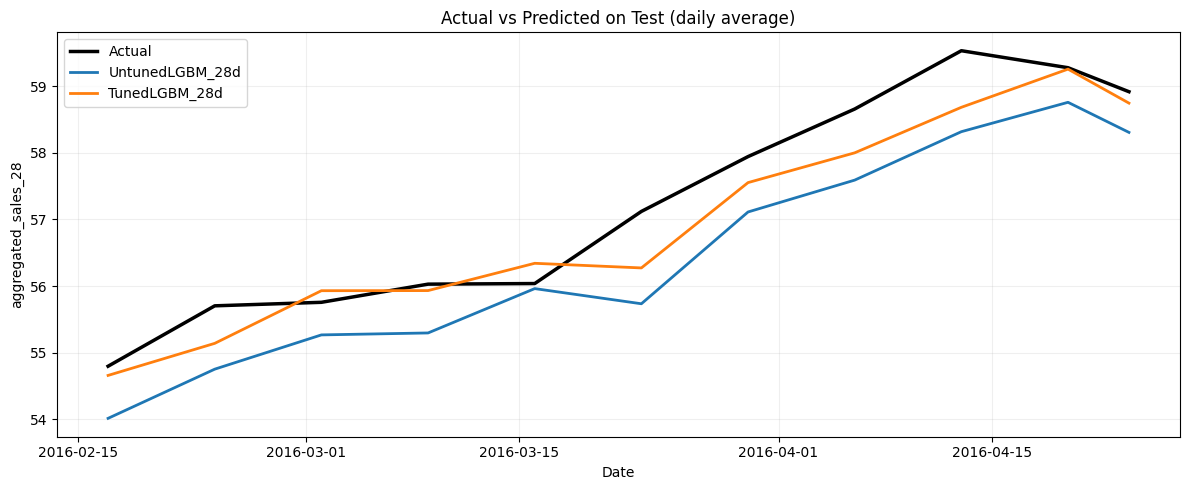

In [9]:
curve_df = X_test[['date']].copy()
curve_df['actual'] = y_test.values
curve_df['untuned'] = pred_untuned_test
curve_df['tuned'] = pred_tuned_test
curve_df = curve_df.groupby('date', as_index=False).mean(numeric_only=True).sort_values('date')

plt.figure(figsize=(12, 5))
plt.plot(curve_df['date'], curve_df['actual'], label='Actual', color='black', linewidth=2.5)
plt.plot(curve_df['date'], curve_df['untuned'], label='UntunedLGBM_28d', linewidth=2)
plt.plot(curve_df['date'], curve_df['tuned'], label='TunedLGBM_28d', linewidth=2)
plt.title('Actual vs Predicted on Test (daily average)')
plt.xlabel('Date')
plt.ylabel('aggregated_sales_28')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 9) Residual Distribution (Test)
This cell compares residual distributions of untuned vs tuned LightGBM on the test split.

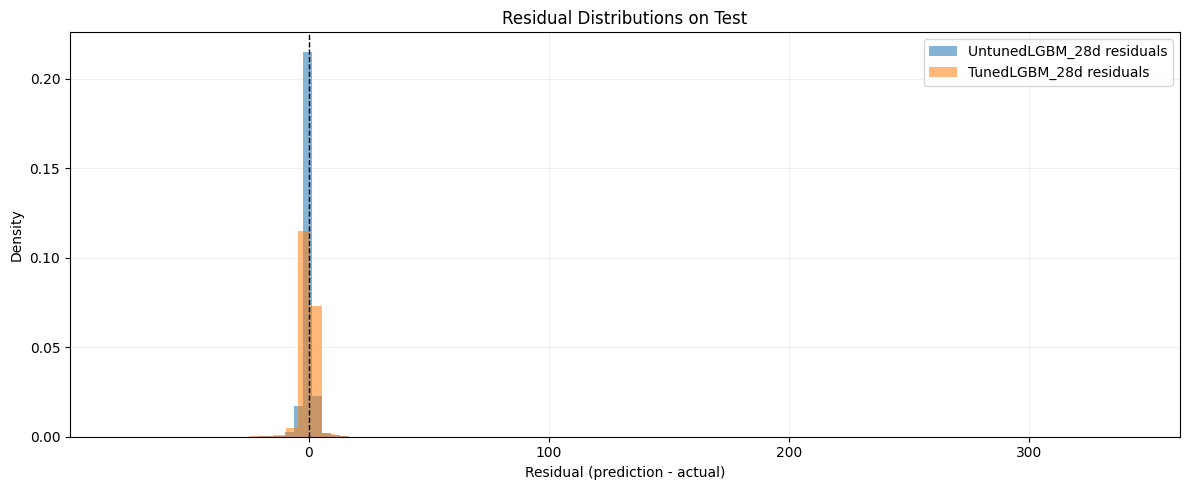

In [9]:
res_untuned = pred_untuned_test - y_test.values
res_tuned = pred_tuned_test - y_test.values

plt.figure(figsize=(12, 5))
plt.hist(res_untuned, bins=80, alpha=0.55, density=True, label='UntunedLGBM_28d residuals')
plt.hist(res_tuned, bins=80, alpha=0.55, density=True, label='TunedLGBM_28d residuals')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Distributions on Test')
plt.xlabel('Residual (prediction - actual)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 10) Save Outputs
This cell saves metrics, val-test gap summary, prediction curves, and best parameters.

In [11]:
metrics_path = REPORTS_DIR / 'metrics_lgbm_28_tuned_vs_untuned.csv'
gap_path = REPORTS_DIR / 'metrics_lgbm_28_val_test_gap_tuned_vs_untuned.csv'
curve_path = REPORTS_DIR / 'predictions_curve_lgbm_28_tuned_vs_untuned.csv'
best_params_path = REPORTS_DIR / 'best_params_lgbm_28_optuna.json'

metrics_df.to_csv(metrics_path, index=False)
gap_df.to_csv(gap_path, index=False)
curve_df.to_csv(curve_path, index=False)

import json
with open(best_params_path, 'w', encoding='utf-8') as f:
    json.dump(best_params, f, indent=2)

print('Saved metrics:', metrics_path)
print('Saved val-test gap:', gap_path)
print('Saved curve:', curve_path)
print('Saved best params:', best_params_path)

Saved metrics: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\metrics_lgbm_28_tuned_vs_untuned.csv
Saved val-test gap: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\metrics_lgbm_28_val_test_gap_tuned_vs_untuned.csv
Saved curve: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\predictions_curve_lgbm_28_tuned_vs_untuned.csv
Saved best params: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\best_params_lgbm_28_optuna.json


In [11]:
import json
import joblib

MODELS_DIR = ROOT / 'artifacts' / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

untuned_model_path = MODELS_DIR / 'untuned_lgbm_28.joblib'
untuned_params_path = MODELS_DIR / 'untuned_lgbm_28_params.json'

joblib.dump(untuned_lgbm, untuned_model_path)

with open(untuned_params_path, 'w', encoding='utf-8') as f:
    json.dump(untuned_params, f, indent=2)

print(f'Saved untuned model: {untuned_model_path}')
print(f'Saved untuned params: {untuned_params_path}')

Saved untuned model: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\untuned_lgbm_28.joblib
Saved untuned params: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\untuned_lgbm_28_params.json
